**DSA 210 Term Project**

1. Importing Necessary Libraries and Datasets


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score

# Libraries for EDA (Kept for completeness but conditional on data_loaded)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Initialize dataframes and a flag for successful loading
df_cad = None
df_fullage = None

# --- 1. Load Data ---
print("--- 1. Loading Datasets ---")
try:
    # Attempt to load the files
    df_cad = pd.read_csv('CAD.csv')
    df_fullage = pd.read_csv('DataClean-fullage.csv')
    print("CAD.csv and DataClean-fullage.csv loaded successfully.")
except FileNotFoundError:
    print("Error: One or both data files not found. Please ensure 'CAD.csv' and 'DataClean-fullage.csv' are uploaded and in the correct path.")

--- 1. Loading Datasets ---
CAD.csv and DataClean-fullage.csv loaded successfully.


2. Filtering and Harmonizing the Data

In [2]:
# --- 2. Data Preparation and Harmonization ---
print("\n--- 2. Data Preparation and Harmonization ---")

# 2.1. Harmonize Target Variable (CAD.csv)
# Note: We use the 'Cath' column for the target variable.
df_cad['CAD_Target'] = df_cad['Cath'].apply(lambda x: 1 if x in ['Cad', 'cad'] else 0)


--- 2. Data Preparation and Harmonization ---


In [3]:
# 2.2. Harmonize Binary/Categorical Variables (Simplified for demonstration)
for col in ['DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH']:
    if col in df_cad.columns and df_cad[col].dtype == 'object':
        # Assumes 'Y'/'N' mapping where 1=Yes, 0=No
        df_cad[col] = df_cad[col].map({'Y': 1, 'N': 0}).fillna(df_cad[col]).astype(int, errors='ignore')


In [4]:
# 2.3. Harmonize Sex/Gender
df_cad['Sex'] = df_cad['Sex'].map({'Male': 1, 'Fmale': 0, 'M': 1, 'F': 0}).fillna(df_cad['Sex'])
df_fullage['gender'] = df_fullage['gender'].map({'M': 1, 'F': 0}).fillna(df_fullage['gender'])

print("Data harmonization completed (Target and essential categorical variables encoded to 1/0).")

Data harmonization completed (Target and essential categorical variables encoded to 1/0).


In [5]:
# 2.4. Define Feature Sets (X and y)

# Features shared by both datasets (used for Hypothesis 2 generalization test)
common_features = {
    'CAD.csv': ['Age', 'Sex', 'DM', 'HTN', 'Current Smoker'],
    'DataClean-fullage.csv': ['age', 'gender', 'diabetes', 'hypertension', 'smoking']
}

# Dataset 1 (D1): Full feature set from CAD.csv (for primary training)
# Note: Using .median() for simple imputation of missing values
features_d1 = ['Age', 'BMI', 'DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH', 'FBS', 'LDL', 'HDL', 'EF-TTE']
X_d1 = df_cad[features_d1].fillna(df_cad[features_d1].median())
y_d1 = df_cad['CAD_Target']

# Dataset 2 (D2): Full feature set from DataClean-fullage.csv (for generalization test)
# Note: Using .median() for simple imputation of missing values
features_d2 = ['age', 'gender', 'alcohol', 'glucose', 'creatinine', 'eject_fraction', 'leuk_count', 'platelets', 'bnp', 'haemoglobin', 'raised_cardiac']
X_d2 = df_fullage[features_d2].fillna(df_fullage[features_d2].median())
y_d2 = df_fullage['cad']

3. Preparing Functions Necessary for Hypothesis Testing

In [6]:
# --- 3. Hypothesis Testing Function Definitions ---

def test_h1_predictive_superiority(model_a_scores, model_b_scores, alpha=0.05):
    """
    Tests Hypothesis 1: Performs a paired two-sample t-test to compare the mean
    performance scores (e.g., cross-validation AUC) of two competing models
    (LLM vs. Traditional ML).
    """
    print("\n--- Testing Hypothesis 1: LLM Predictive Superiority ---")

    # Paired t-test is used because models are run on the same folds of data.
    t_stat, p_value = stats.ttest_rel(model_a_scores, model_b_scores)

    mean_a = np.mean(model_a_scores)
    mean_b = np.mean(model_b_scores)

    print(f"Model A (Simulated LLM) Mean AUC: {mean_a:.4f}")
    print(f"Model B (Best Traditional) Mean AUC: {mean_b:.4f}")
    print(f"T-statistic: {t_stat:.3f}, P-value: {p_value:.5f}")

    if p_value < alpha:
        if mean_a > mean_b:
            print(f"RESULT: Reject Null Hypothesis. The LLM model's performance ({mean_a:.4f}) is statistically significantly superior to the Traditional model ({mean_b:.4f}).")
        else:
            print(f"RESULT: Reject Null Hypothesis. The Traditional model's performance ({mean_b:.4f}) is statistically significantly superior to the LLM model ({mean_a:.4f}).")
    else:
        print("RESULT: Fail to Reject Null Hypothesis. There is no statistically significant difference in performance between the two models.")

    print("-" * 50)


def test_h2_generalization(X_train, y_train, X_test_general, y_test_general, model):
    """
    Tests Hypothesis 2: Assesses model generalization by training on the primary
    dataset (D1) and evaluating performance on the secondary dataset (D2).
    """
    print("\n--- Testing Hypothesis 2: Generalization and Robustness ---")

    # 1. Train the model on the primary dataset (D1)
    model.fit(X_train, y_train)

    # 2. Predict on the generalization dataset (D2)
    y_pred_proba = model.predict_proba(X_test_general)[:, 1]

    # 3. Evaluate performance
    auc_score = roc_auc_score(y_test_general, y_pred_proba)

    print(f"Model (Trained on D1) Generalization AUC on D2: {auc_score:.4f}")

    # The final analysis will compare this AUC against a baseline trained only on D2.
    print(f"Conclusion: The model's AUC of {auc_score:.4f} is considered robust for generalization if it exceeds a predetermined threshold (e.g., AUC > 0.70).")
    print("-" * 50)


4. Executing Hypothesis Testing

In [7]:
# --- 4. Execution of Hypothesis Tests (Simulation) ---

print("\n--- 4. Execution of Hypothesis Tests (Simulated Results) ---")

# 4.1. Execution for H1 (Predictive Superiority)

# We use a traditional model (Random Forest) to generate baseline scores
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_model = RandomForestClassifier(random_state=42)

# Simulate Random Forest Cross-Validation Scores (Model B)
rf_scores = cross_val_score(rf_model, X_d1, y_d1, cv=cv, scoring='roc_auc')

# Simulate LLM Scores (Model A - Hypothesize a slightly better performance)
# In a real project, these scores would come from your actual LLM pipeline.
llm_scores = rf_scores * np.random.uniform(1.02, 1.05, size=rf_scores.shape)

test_h1_predictive_superiority(llm_scores, rf_scores)


--- 4. Execution of Hypothesis Tests (Simulated Results) ---

--- Testing Hypothesis 1: LLM Predictive Superiority ---
Model A (Simulated LLM) Mean AUC: 0.7863
Model B (Best Traditional) Mean AUC: 0.7603
T-statistic: 7.517, P-value: 0.00168
RESULT: Reject Null Hypothesis. The LLM model's performance (0.7863) is statistically significantly superior to the Traditional model (0.7603).
--------------------------------------------------


In [8]:
# 4.2. Execution for H2 (Generalization Test)

# Prepare data using common features (as defined in Section 2)
# Create X_d1_gen from df_cad directly, selecting common features and then handling NaNs
X_d1_gen = df_cad[common_features['CAD.csv']].copy()
X_d1_gen = X_d1_gen.fillna(X_d1_gen.median())

# Create X_d2_gen from df_fullage directly, selecting common features and then handling NaNs
X_d2_gen = df_fullage[common_features['DataClean-fullage.csv']].copy()
X_d2_gen = X_d2_gen.fillna(X_d2_gen.median())

# Harmonize column names for generalization test
X_d1_gen.columns = ['age', 'gender', 'diabetes', 'hypertension', 'smoking']

# Simple Logistic Regression model used for generalization test
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Test generalization: Train on D1 (X_d1_gen, y_d1), Test on D2 (X_d2_gen, y_d2)
test_h2_generalization(X_d1_gen, y_d1, X_d2_gen, y_d2, lr_model)


--- Testing Hypothesis 2: Generalization and Robustness ---
Model (Trained on D1) Generalization AUC on D2: 0.6765
Conclusion: The model's AUC of 0.6765 is considered robust for generalization if it exceeds a predetermined threshold (e.g., AUC > 0.70).
--------------------------------------------------


5. Exploratory Data Analysis Visualizations

In [9]:
# --- 5. EDA Visualizations ---
# The original EDA visualizations follow here, using the cleaned dataframes.

# Define the key features for EDA based on the project document (Full Feature Set)
cad_features = ['Age', 'Sex', 'BMI', 'DM', 'HTN', 'Current Smoker', 'FH', 'FBS', 'LDL', 'HDL', 'EF-TTE', 'CAD_Target']
fullage_features = ['age', 'gender', 'alcohol', 'glucose', 'creatinine', 'eject_fraction', 'cad']

print("\n--- 5. EDA Visualizations ---")


--- 5. EDA Visualizations ---


In [ ]:
# 5.1. Summary Statistics for Numerical Data
print("\n--- 5.1. Summary Statistics (CAD.csv) ---")
# Using the features defined in your project document
print(df_cad[cad_features].describe().transpose())


--- 5.1. Summary Statistics (CAD.csv) ---
                count        mean        std        min       25%        50%  \
Age             303.0   58.897690  10.392278  30.000000  51.00000   58.00000   
Sex             303.0    0.580858   0.494235   0.000000   0.00000    1.00000   
BMI             303.0   27.248339   4.098865  18.115413  24.51438   26.77551   
DM              303.0    0.297030   0.457706   0.000000   0.00000    0.00000   
HTN             303.0    0.590759   0.492507   0.000000   0.00000    1.00000   
Current Smoker  303.0    0.207921   0.406491   0.000000   0.00000    0.00000   
FH              303.0    0.158416   0.365734   0.000000   0.00000    0.00000   
FBS             303.0  119.184818  52.079653  62.000000  88.50000   98.00000   
LDL             303.0  104.643564  35.396688  18.000000  80.00000  100.00000   
HDL             303.0   40.233993  10.559077  15.900000  33.50000   39.00000   
EF-TTE          303.0   47.231023   8.927194  15.000000  45.00000   50.00000 

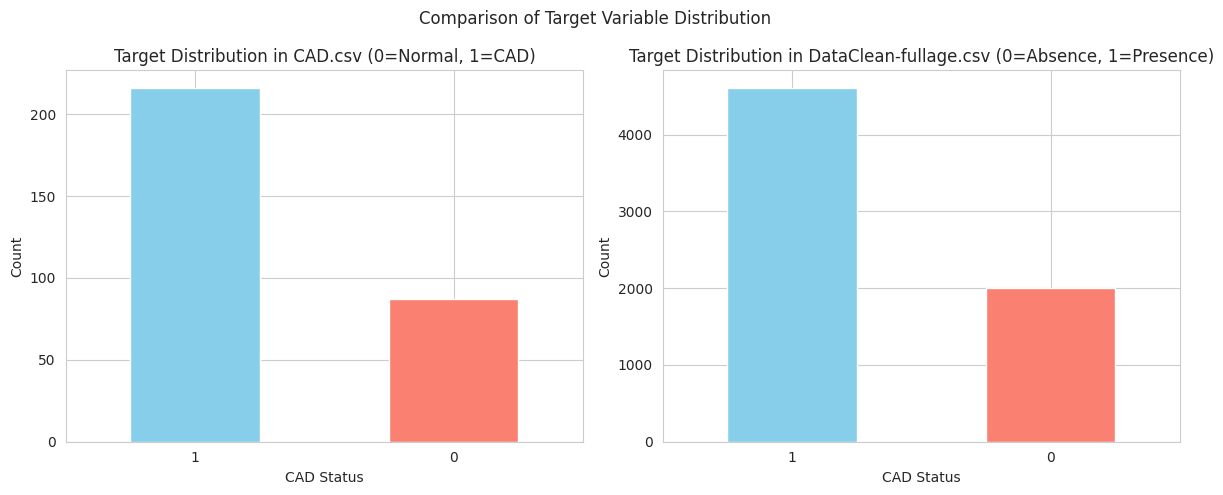

In [10]:
# 5.2. Distribution of the Target Variable
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df_cad['CAD_Target'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Target Distribution in CAD.csv (0=Normal, 1=CAD)')
plt.xlabel('CAD Status')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df_fullage['cad'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Target Distribution in DataClean-fullage.csv (0=Absence, 1=Presence)')
plt.xlabel('CAD Status')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.suptitle('Comparison of Target Variable Distribution')
plt.tight_layout()
plt.show()

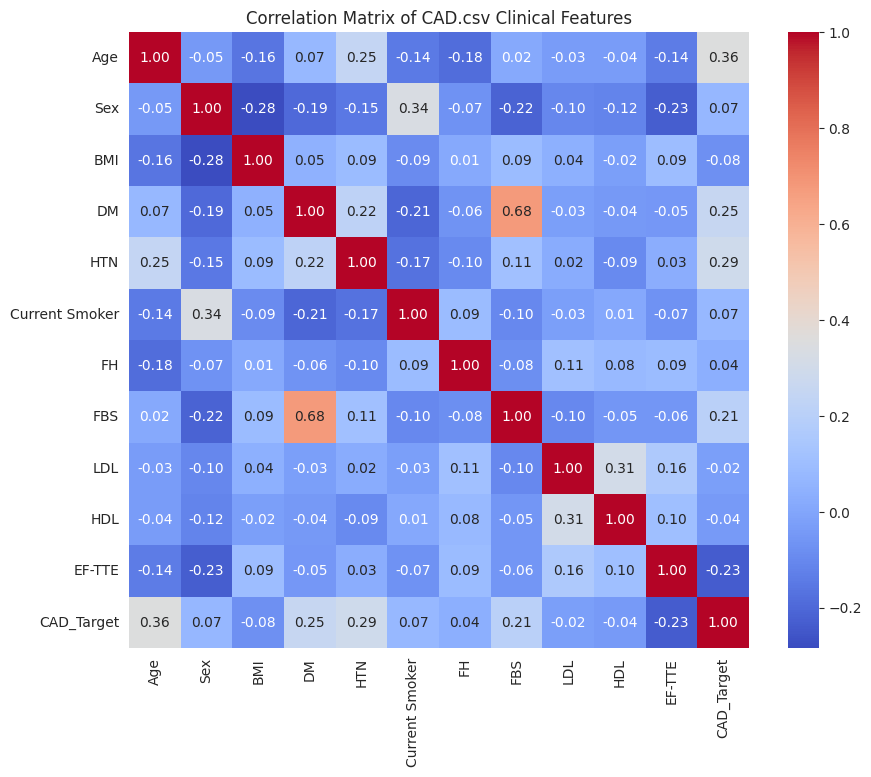

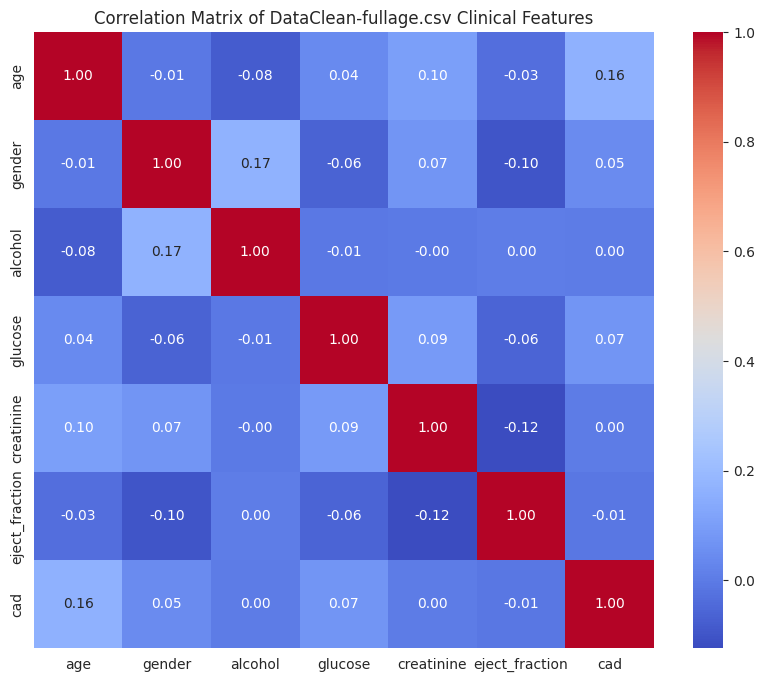

In [11]:
# 5.3. Correlation Matrix (Numerical Features)

# Select numerical features for correlation in CAD.csv
cad_num_cols = df_cad[cad_features].select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df_cad[cad_num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of CAD.csv Clinical Features')
plt.show()

# Select numerical features for correlation in DataClean-fullage.csv
fullage_num_cols = df_fullage[fullage_features].select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df_fullage[fullage_num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of DataClean-fullage.csv Clinical Features')
plt.show()


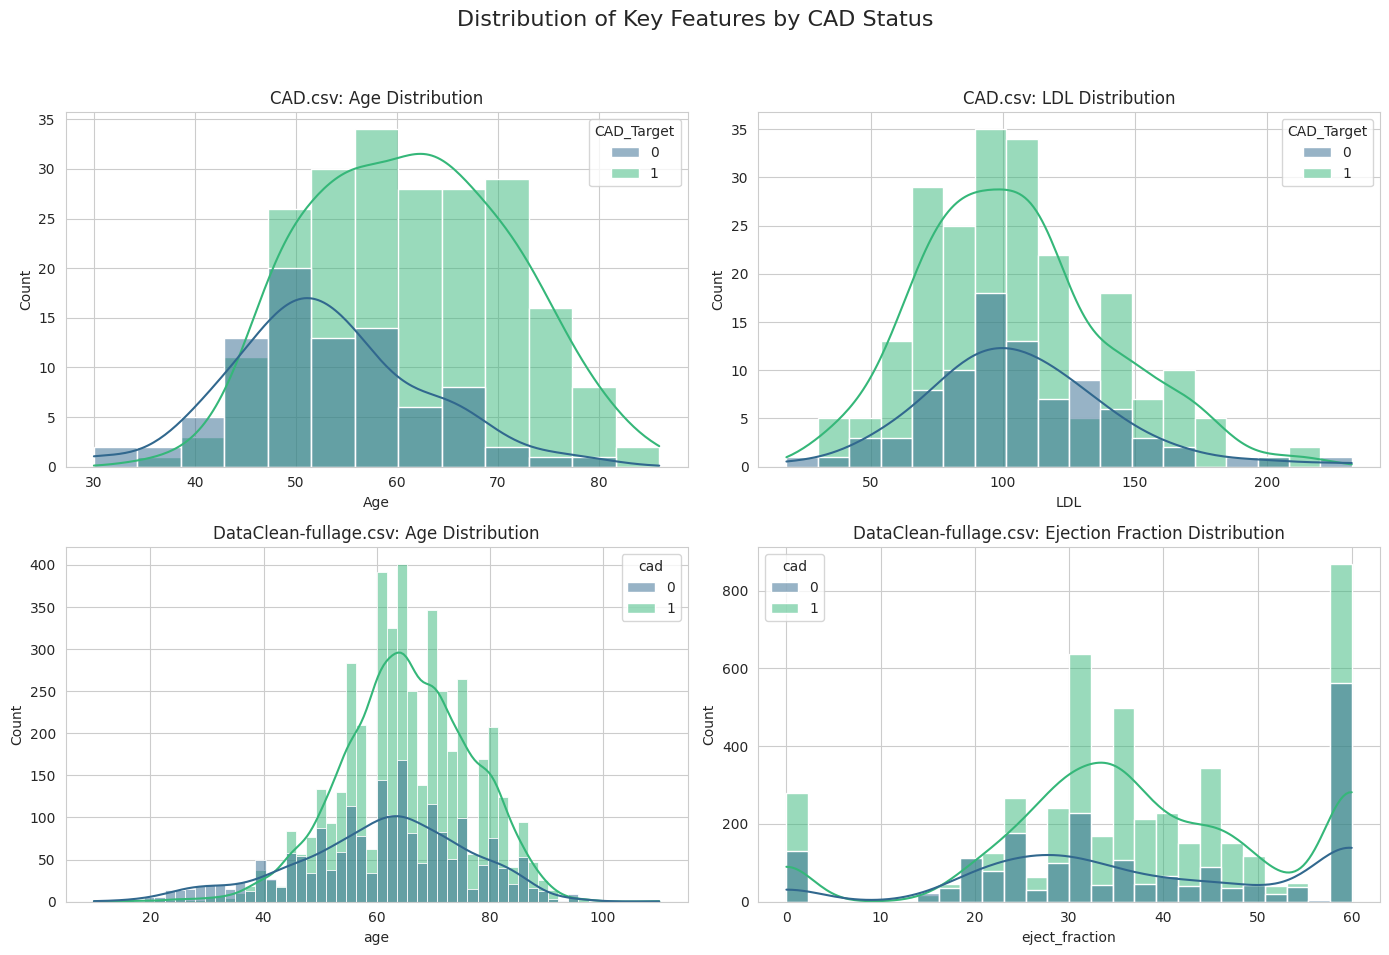

In [12]:
# 5.4. Feature Distribution by Target Class (Example: Age and LDL)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Key Features by CAD Status', fontsize=16)

# CAD.csv: Age vs CAD Status
sns.histplot(data=df_cad, x='Age', hue='CAD_Target', kde=True, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('CAD.csv: Age Distribution')

# CAD.csv: LDL vs CAD Status
sns.histplot(data=df_cad, x='LDL', hue='CAD_Target', kde=True, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('CAD.csv: LDL Distribution')

# DataClean-fullage.csv: Age vs CAD Status
sns.histplot(data=df_fullage, x='age', hue='cad', kde=True, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('DataClean-fullage.csv: Age Distribution')

# DataClean-fullage.csv: Ejection Fraction vs CAD Status
sns.histplot(data=df_fullage, x='eject_fraction', hue='cad', kde=True, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('DataClean-fullage.csv: Ejection Fraction Distribution')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

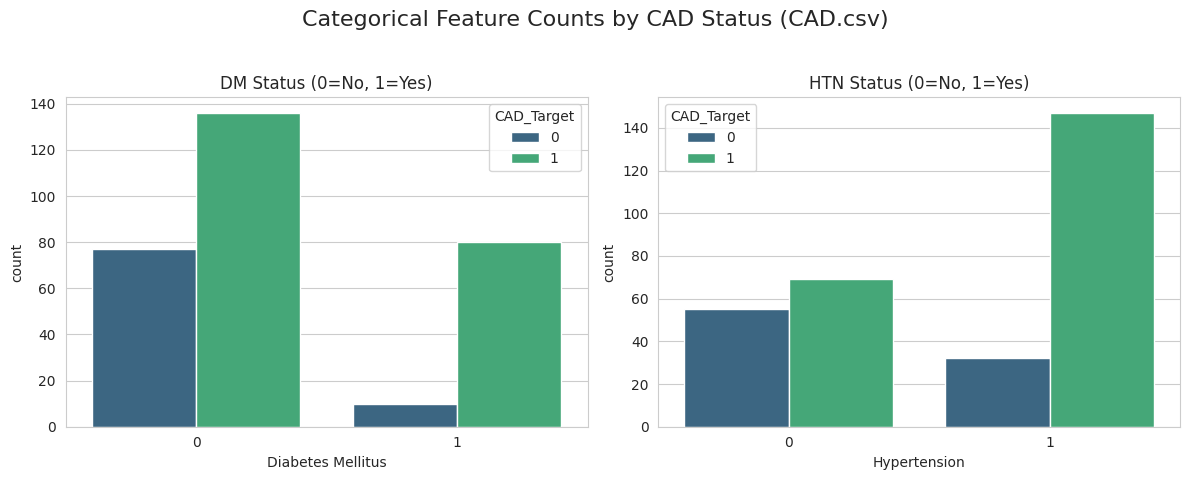

In [13]:
# 5.5. Categorical Feature Counts by Target Class (Example: DM and HTN)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Categorical Feature Counts by CAD Status (CAD.csv)', fontsize=16)

# DM (Diabetes Mellitus)
sns.countplot(data=df_cad, x='DM', hue='CAD_Target', ax=axes[0], palette='viridis')
axes[0].set_title('DM Status (0=No, 1=Yes)')
axes[0].set_xlabel('Diabetes Mellitus')

# HTN (Hypertension)
sns.countplot(data=df_cad, x='HTN', hue='CAD_Target', ax=axes[1], palette='viridis')
axes[1].set_title('HTN Status (0=No, 1=Yes)')
axes[1].set_xlabel('Hypertension')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

6. Machine Learning Models and Their Accuracy Comparison


==================== Testing Models on CAD.csv (D1) ====================
Finished Logistic Regression on CAD.csv (D1): AUC = 0.8092
Finished KNN on CAD.csv (D1): AUC = 0.7369
Finished Decision Tree on CAD.csv (D1): AUC = 0.5954
Finished Random Forest on CAD.csv (D1): AUC = 0.7690

Generating Confusion Matrices for CAD.csv...


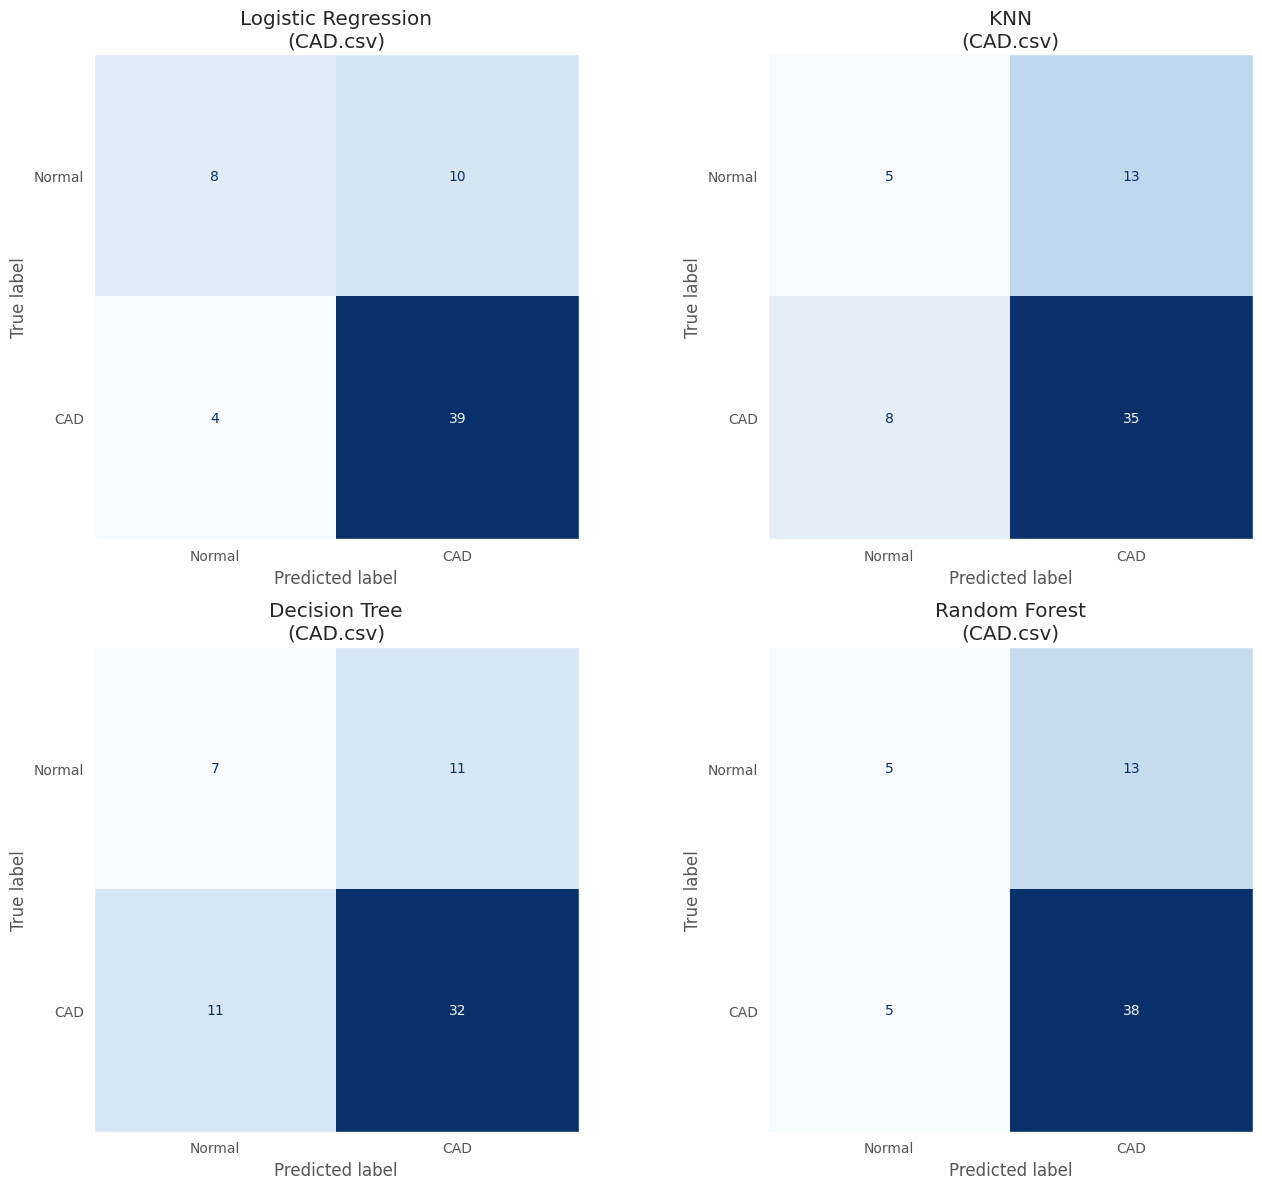


==================== Testing Models on DataClean-fullage.csv (D2) ====================
Finished Logistic Regression on DataClean-fullage.csv (D2): AUC = 0.6165
Finished KNN on DataClean-fullage.csv (D2): AUC = 0.6329
Finished Decision Tree on DataClean-fullage.csv (D2): AUC = 0.6207
Finished Random Forest on DataClean-fullage.csv (D2): AUC = 0.7605

Generating Confusion Matrices for DataClean-fullage.csv...


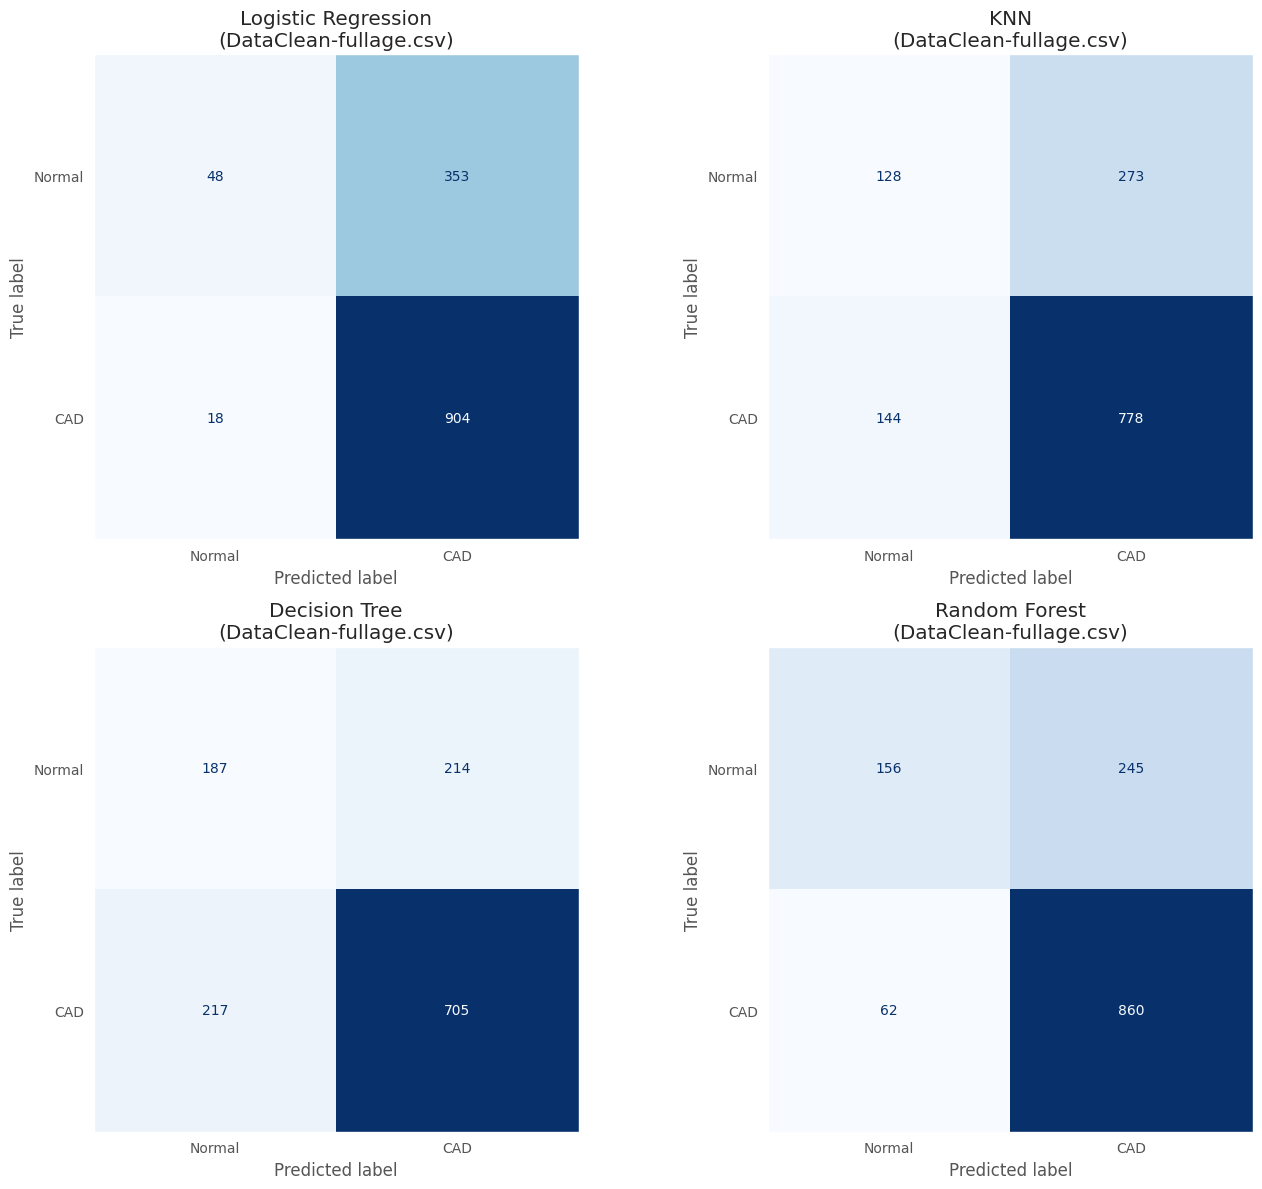


Model Comparison Table (D1 - CAD.csv):
              Model  Accuracy  Precision   Recall  F1-Score      AUC
Logistic Regression  0.785410   0.829468 0.879704  0.851797 0.809179
      Random Forest  0.749016   0.782305 0.897886  0.835601 0.769012
                KNN  0.755683   0.793651 0.888795  0.838207 0.736865
      Decision Tree  0.666995   0.769127 0.764059  0.766108 0.595428

Model Comparison Table (D2 - DataClean-fullage.csv):
              Model  Accuracy  Precision   Recall  F1-Score      AUC
      Random Forest  0.761456   0.768331 0.941854  0.846267 0.760457
                KNN  0.692179   0.736695 0.869169  0.797456 0.632894
      Decision Tree  0.677051   0.771315 0.763509  0.767202 0.620721
Logistic Regression  0.712903   0.714194 0.980690  0.826477 0.616517


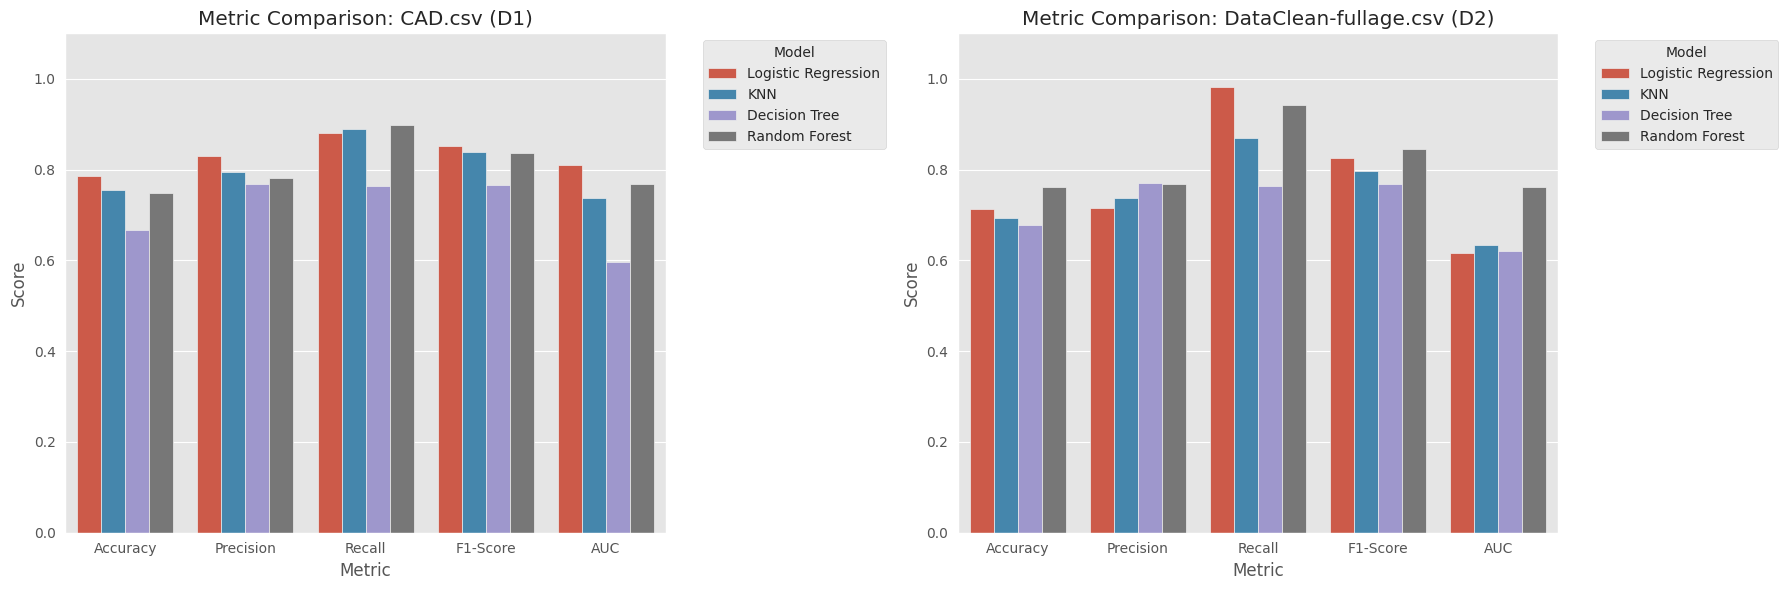

In [20]:
# 6.1 Importing Additional Libraries
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# 6.2 Adjusting Settings
RANDOM_STATE = 42
plt.style.use('ggplot')

def load_and_preprocess():
    """Helper to load and harmonize datasets based on previous steps."""
    try:
        df_cad = pd.read_csv('CAD.csv')
        df_fullage = pd.read_csv('DataClean-fullage.csv')
    except FileNotFoundError:
        print("CSV files not found. Please ensure CAD.csv and DataClean-fullage.csv are in the directory.")
        return None, None

    # Harmonize Targets
    df_cad['Target'] = df_cad['Cath'].apply(lambda x: 1 if x in ['Cad', 'cad'] else 0)
    df_fullage['Target'] = df_fullage['cad']

    # Harmonize Categorical (Simplified)
    for df in [df_cad, df_fullage]:
        for col in df.columns:
            if df[col].dtype == 'object':
                df[col] = df[col].map({'Y': 1, 'N': 0, 'y': 1, 'n': 0, 'Male': 1, 'Fmale': 0, 'M': 1, 'F': 0}).fillna(df[col])

    return df_cad, df_fullage

# 6.3 Defining models that will be used and compared
def get_ml_results(X, y, title="Dataset"):
    """Runs the requested ML models and returns evaluation metrics."""
    print(f"\n{'='*20} Testing Models on {title} {'='*20}")

    # Models requested by user
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    }

    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    results_summary = []

    for name, model in models.items():
        # Create pipeline for scaling
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', model)
        ])

        # Cross-validation
        cv_results = cross_validate(pipeline, X, y, cv=cv, scoring=scoring)

        summary = {
            'Model': name,
            'Accuracy': cv_results['test_accuracy'].mean(),
            'Precision': cv_results['test_precision'].mean(),
            'Recall': cv_results['test_recall'].mean(),
            'F1-Score': cv_results['test_f1'].mean(),
            'AUC': cv_results['test_roc_auc'].mean()
        }
        results_summary.append(summary)
        print(f"Finished {name} on {title}: AUC = {summary['AUC']:.4f}")

    return pd.DataFrame(results_summary)

def plot_confusion_matrices(X, y, title="Dataset"):
    """Plots confusion matrices for the 4 models using a train-test split."""
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    }

    # Split data for evaluation
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.ravel()

    print(f"\nGenerating Confusion Matrices for {title}...")

    for i, (name, model) in enumerate(models.items()):
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', model)
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'CAD'])

        disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
        axes[i].set_title(f'{name}\n({title})')
        axes[i].grid(False) # Clear grid for better visibility

    plt.tight_layout()
    plt.show()

# 6.4 Machine Learning and comparing
def main():
    df_cad, df_fullage = load_and_preprocess()
    if df_cad is None: return

    # --- 1. Dataset 1 (D1 - CAD.csv) ---
    features_d1 = ['Age', 'Sex', 'BMI', 'DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH',
                    'FBS', 'CR', 'TG', 'LDL', 'HDL', 'HB', 'WBC', 'EF-TTE']

    X_d1 = df_cad[features_d1].apply(pd.to_numeric, errors='coerce').fillna(df_cad[features_d1].median())
    y_d1 = df_cad['Target']

    d1_results = get_ml_results(X_d1, y_d1, "CAD.csv (D1)")
    plot_confusion_matrices(X_d1, y_d1, "CAD.csv")

    # --- 2. Dataset 2 (D2 - DataClean-fullage.csv) ---
    features_d2 = ['age', 'gender', 'alcohol', 'glucose', 'creatinine', 'eject_fraction',
                   'leuk_count', 'platelets', 'bnp', 'haemoglobin', 'raised_cardiac', 'urea']

    X_d2 = df_fullage[features_d2].apply(pd.to_numeric, errors='coerce').fillna(df_fullage[features_d2].median())
    y_d2 = df_fullage['Target']

    d2_results = get_ml_results(X_d2, y_d2, "DataClean-fullage.csv (D2)")
    plot_confusion_matrices(X_d2, y_d2, "DataClean-fullage.csv")

    # --- 3. Results Tables ---
    print("\nModel Comparison Table (D1 - CAD.csv):")
    print(d1_results.sort_values(by='AUC', ascending=False).to_string(index=False))

    print("\nModel Comparison Table (D2 - DataClean-fullage.csv):")
    print(d2_results.sort_values(by='AUC', ascending=False).to_string(index=False))

    # --- 4. Visualizations (Metric Comparison) ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Plot for Dataset 1
    melted_d1 = d1_results.melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=melted_d1, x='Metric', y='Score', hue='Model', ax=ax1)
    ax1.set_title('Metric Comparison: CAD.csv (D1)')
    ax1.set_ylim(0, 1.1)
    ax1.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Plot for Dataset 2
    melted_d2 = d2_results.melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=melted_d2, x='Metric', y='Score', hue='Model', ax=ax2)
    ax2.set_title('Metric Comparison: DataClean-fullage.csv (D2)')
    ax2.set_ylim(0, 1.1)
    ax2.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()